# Fitting Variograms for an MGSIM Config

MGSIM simulates the **normal-score-transformed, trend-subtracted residuals** of the data, with a
separate variogram per clustered subregion. The config file freezes those variograms as a
`variograms_list` — one entry per cluster, in gstatsim's format:

```
[azimuth, nugget, major_range, minor_range, sill, model]
```

This notebook shows where those numbers come from, end to end:

1. fit a smooth **trend** to the flight-line data (`make_trend`),
2. compute **residuals** (data − trend) at the observation points,
3. **normal-score transform** (NST) the residuals,
4. fit a **variogram per subregion** to the transformed residuals,
5. assemble the entries

Everything here is part of one **fully seeded chain**: `demo_asm.ipynb` regenerates the dataset's
`cluster` column from the raw flight lines, this notebook regenerates its `trend` column and the
config's variograms, and `demo_interpolation.ipynb` consumes the config with seeded ensembles —
so the whole repo is reproducible from the raw data (`demos/data/fl_xyvc.csv`) onward.
(Same-machine reruns are exact; across platforms, tiny floating-point differences can appear.)


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from skgstat import models as skmodels

from multigrid_sgsim import cluster_variogram
from multigrid_sgsim.trendmaking import make_trend

# Paths — relative to the repo (this notebook runs from demos/)
REPO   = Path.cwd().resolve().parent
CONFIG = REPO / 'config' / 'config_mgsim_clusteriso_medium.json'

with open(CONFIG) as f:
    cfg = json.load(f)
df_data = pd.read_csv(REPO / cfg['data_file'])
obs = df_data[df_data['set'] == 1].copy()
obs['cluster'] = obs['cluster'].astype(int)

# Fitting choices, frozen in the config's metadata
meta = cfg['metadata']
MAXLAG, N_LAGS = meta['maxlag'], meta['n_lags']
VGM_MODEL = meta['variogram_model']            # 'gaussian'
n_clusters = len(cfg['variograms_list'])
ROWS, COLS = cfg['grid_shape']

print(f'{len(obs)} flight-line observations, {n_clusters} subregions')
print(f"variogram fitting: model={VGM_MODEL}, maxlag={MAXLAG}, n_lags={N_LAGS}")
print(f"trend provenance: {meta['trend']}")


1667 flight-line observations, 4 subregions
variogram fitting: model=gaussian, maxlag=40, n_lags=40
trend provenance: {'trend_method': 'RBF smoothing (trendmaking.make_trend)', 'smoothing': 1000.0, 'linespacing': 20, 'random_state': 0, 'source_flightlines': 'demos/data/fl_xyvc.csv', 'note': 'trend values stored per grid point in the data CSV `trend` column; make_trend(random_state=0) regenerates them exactly'}


## 1. The trend

MGSIM decomposes the field as $z(x) = m(x) + r(x)$: a smooth trend $m$ plus residuals $r$.
`make_trend` builds $m$ by stratified-subsampling and fitting a smoothed thin-plate-spline RBF — the `smoothing` and `linespacing`
parameters recorded in the config metadata.

Different `random_state` values give visibly
different smooth trends. That is fine for the method: the decomposition $z = m + r$ is not unique,
and MGSIM updates the trend at every multigrid pass. But the config's variograms belong to one
*specific* trend, so the chain fixes the draw with `random_state` (recorded in the config
metadata). Below we regenerate that exact trend from the raw flight lines and verify it matches
the dataset's `trend` column.


make_trend(random_state=0) reproduces the shipped trend column exactly (max|diff| = 5.7e-14 nT).
Try a different random_state to see how much a different — equally valid — draw changes m0.


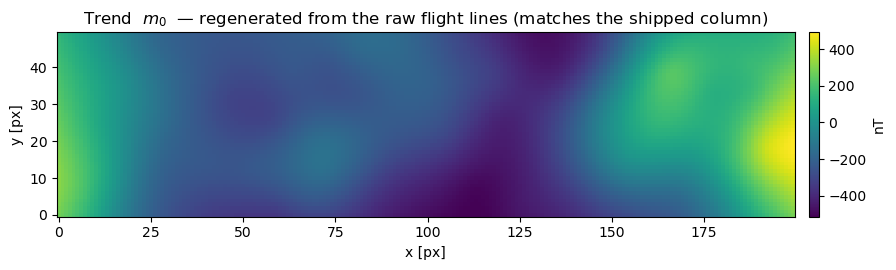

In [2]:
fl_xyvc  = obs[['x', 'y', 'value', 'cluster']].values
grid_xyc = df_data[['x', 'y', 'cluster']].values

_, grid_xyct = make_trend(fl_xyvc, grid_xyc,
                          smoothing=meta['trend']['smoothing'],
                          linespacing=meta['trend']['linespacing'],
                          random_state=meta['trend']['random_state'])
trend_recomputed = grid_xyct[:, -1].reshape(ROWS, COLS)
trend_shipped    = df_data['trend'].values.reshape(ROWS, COLS)

assert np.allclose(trend_recomputed, trend_shipped, rtol=0, atol=1e-8),     'recomputed trend differs from the shipped trend column'
print(f"make_trend(random_state={meta['trend']['random_state']}) reproduces the shipped "
      f"trend column exactly (max|diff| = {np.abs(trend_recomputed - trend_shipped).max():.2g} nT).")
print('Try a different random_state to see how much a different — equally valid — draw changes m0.')

fig, ax = plt.subplots(figsize=(15, 2.8))
im = ax.imshow(trend_shipped, origin='lower', cmap='viridis')
ax.set_title('Trend  $m_0$  — regenerated from the raw flight lines (matches the shipped column)')
ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
plt.colorbar(im, ax=ax, label='nT', pad=0.01)
plt.tight_layout(); plt.show()


## 2. Residuals and the normal-score transform

Sequential Gaussian simulation assumes a standard-normal field, so the residuals are
normal-score transformed before fitting: a `QuantileTransformer` maps their empirical
distribution to $N(0, 1)$. The variograms are fitted to these **NST residuals** — the exact field
MGSIM simulates — so their sills are in NST units (order 1), not nT².

This is the same transformer construction `demo_interpolation.ipynb` uses before calling
`mgsim(nst_trans=...)`: fitted on the observation residuals only.


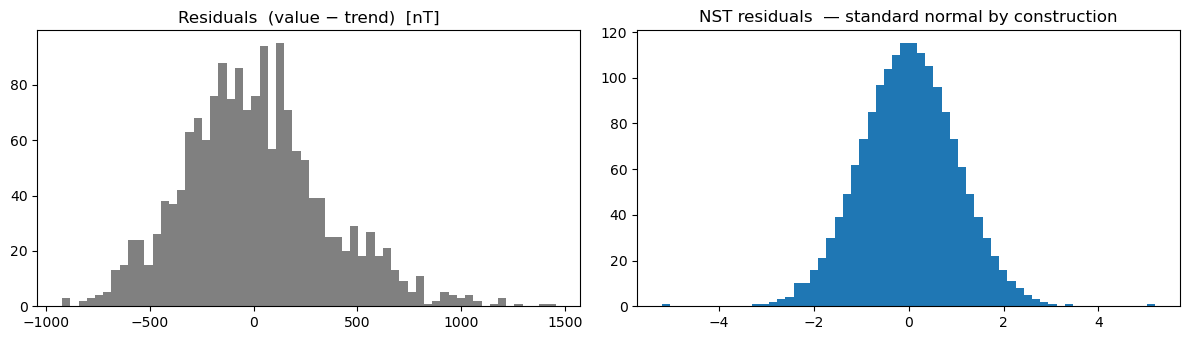

residuals: mean=6.6 nT, std=346.9 nT
NST residuals: mean=-0.000, std=1.012


In [3]:
obs['residual'] = obs['value'] - obs['trend']

res = obs[['residual']].values
nst = QuantileTransformer(output_distribution='normal',
                          n_quantiles=min(1000, len(res))).fit(res)
obs['Nresidual'] = nst.transform(res).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(obs['residual'], bins=60, color='gray')
axes[0].set_title('Residuals  (value − trend)  [nT]')
axes[1].hist(obs['Nresidual'], bins=60, color='C0')
axes[1].set_title('NST residuals  — standard normal by construction')
plt.tight_layout(); plt.show()

print(f"residuals: mean={obs['residual'].mean():.1f} nT, std={obs['residual'].std():.1f} nT")
print(f"NST residuals: mean={obs['Nresidual'].mean():.3f}, std={obs['Nresidual'].std():.3f}")


## 3. Per-subregion variogram fits

`cluster_variogram` computes the empirical variogram of one cluster's points and fits the chosen
model (Gaussian here). Each subregion gets its own range and sill — this is how MGSIM respects
non-stationarity instead of averaging it away with one global variogram.

The fits below are isotropic (`azimuth=None`), so the config entry repeats the fitted range as
both `major_range` and `minor_range`. For anisotropic data, fit directional variograms
(`azimuth=`, `bandwidth=`) along and across the anisotropy and use the two ranges.


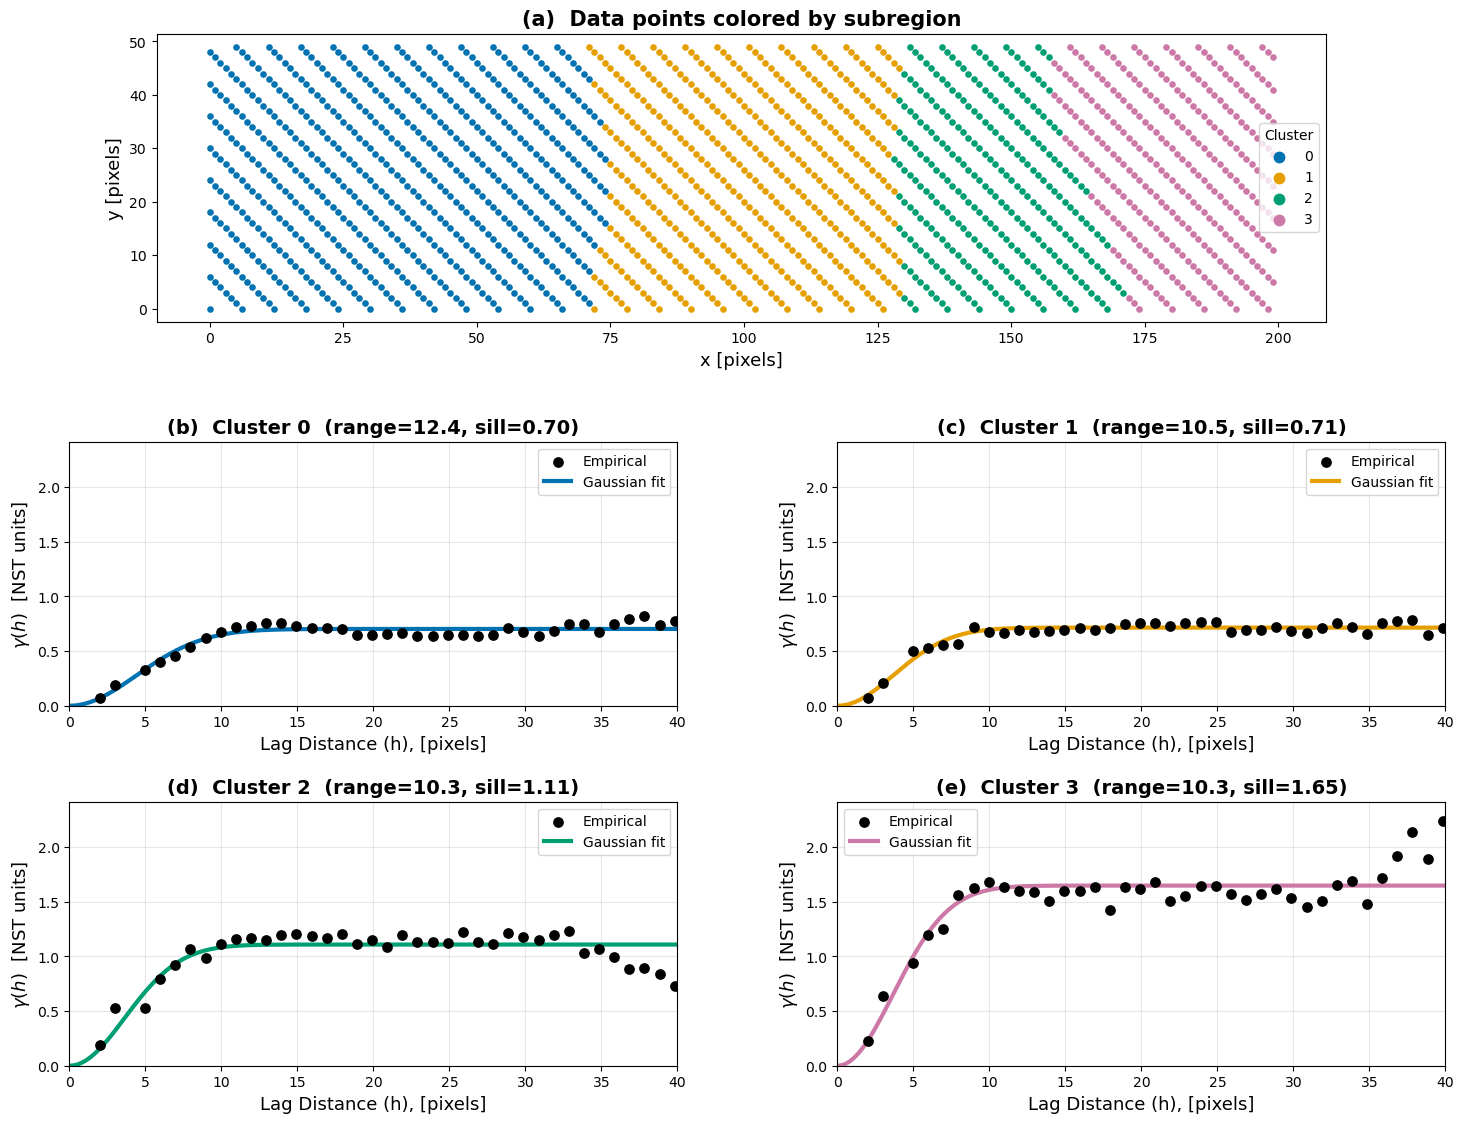

In [4]:
cluster_colors = {0: '#0072B2', 1: '#E69F00', 2: '#009E73', 3: '#CC79A7'}   # Wong palette

fits = []       # per-cluster skg.Variogram objects
for ci in range(n_clusters):
    V = cluster_variogram(obs, 'Nresidual', ci, MAXLAG, N_LAGS, VGM_MODEL)
    fits.append(V)

fig = plt.figure(figsize=(16, 12))
ax_a = fig.add_axes([0.08, 0.68, 0.84, 0.24])
for ci in range(n_clusters):
    m = obs['cluster'] == ci
    ax_a.scatter(obs.loc[m, 'x'], obs.loc[m, 'y'], c=cluster_colors[ci], s=14, label=f'{ci}',
                 rasterized=True)
ax_a.set_xlabel('x [pixels]', fontsize=13); ax_a.set_ylabel('y [pixels]', fontsize=13)
ax_a.set_title('(a)  Data points colored by subregion', fontsize=15, fontweight='bold')
ax_a.set_aspect('equal'); ax_a.legend(title='Cluster', markerscale=2, fontsize=10)

positions = [[0.08, 0.36, 0.38, 0.22], [0.56, 0.36, 0.38, 0.22],
             [0.08, 0.06, 0.38, 0.22], [0.56, 0.06, 0.38, 0.22]]
panel_labels = ['(b)', '(c)', '(d)', '(e)']
h = np.linspace(0, MAXLAG, 200)
y_max = 1.08 * max(np.nanmax(V.experimental) for V in fits)

for ci, V in enumerate(fits):
    r_c, s_c, n_c = V.parameters
    ax = fig.add_axes(positions[ci])
    ax.scatter(V.bins, V.experimental, c='black', s=45, zorder=3, label='Empirical')
    ax.plot(h, skmodels.gaussian(h, r_c, s_c, n_c), color=cluster_colors[ci], lw=3,
            label='Gaussian fit')
    ax.set_xlabel('Lag Distance (h), [pixels]', fontsize=13)
    ax.set_ylabel(r'$\gamma(h)$  [NST units]', fontsize=13)
    ax.set_title(f'{panel_labels[ci]}  Cluster {ci}  (range={r_c:.1f}, sill={s_c:.2f})',
                 fontsize=14, fontweight='bold')
    ax.set_xlim(0, MAXLAG); ax.set_ylim(0, y_max)
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
plt.show()


## 4. Assembling the config entries

Each fit becomes one `variograms_list` entry. The nugget is set to 0 (fitted nuggets on NST
residuals here are negligible), azimuth 0, and the range repeated for the isotropic case.
The check against the shipped config must say **EXACT** for every cluster — same data, same
trend, same transform, same fit (agreement to ~1e-8, the fit optimizer's convergence tolerance).


In [ ]:
variograms_list = []
for V in fits:
    r_c, s_c, _n = V.parameters
    variograms_list.append([0.0, 0, r_c, r_c, s_c, VGM_MODEL.capitalize()])

print('variograms_list for the config JSON:\n')
print(json.dumps({'variograms_list': variograms_list}, indent=2))

print(f"\n{'cluster':<8} {'refit range':<14} {'config range':<14} "
      f"{'refit sill':<13} {'config sill':<13} match")
all_exact = True
for ci, (fitted, frozen) in enumerate(zip(variograms_list, cfg['variograms_list'])):
    ok = np.allclose(fitted[2:5:2], frozen[2:5:2], rtol=0, atol=1e-6)
    all_exact &= ok
    print(f'{ci:<8} {fitted[2]:<14.6f} {frozen[2]:<14.6f} '
          f'{fitted[4]:<13.6f} {frozen[4]:<13.6f} {"EXACT" if ok else "DIFFERS"}')
assert all_exact, 'refit does not reproduce the shipped config'
print('\nRefit reproduces the shipped config.')


variograms_list for the config JSON:

{
  "variograms_list": [
    [
      0.0,
      0,
      12.449382813690695,
      12.449382813690695,
      0.7026043094843165,
      "Gaussian"
    ],
    [
      0.0,
      0,
      10.470258624024584,
      10.470258624024584,
      0.7148217199394187,
      "Gaussian"
    ],
    [
      0.0,
      0,
      10.272831596008338,
      10.272831596008338,
      1.1089324230066862,
      "Gaussian"
    ],
    [
      0.0,
      0,
      10.318183037373064,
      10.318183037373064,
      1.6484781518324858,
      "Gaussian"
    ]
  ]
}

cluster  refit range    config range   refit sill    config sill   match
0        12.449383      12.449383      0.702604      0.702604      EXACT
1        10.470259      10.470259      0.714822      0.714822      EXACT
2        10.272832      10.272832      1.108932      1.108932      EXACT
3        10.318183      10.318183      1.648478      1.648478      EXACT

Refit reproduces the shipped config (agreement to ~1e